In [1]:
import hoda
import tensorly as tl
%pip install toeplitzlda
print(tl.get_backend())
%pip freeze | grep moabb

Note: you may need to restart the kernel to use updated packages.
numpy
moabb==1.0.0
Note: you may need to restart the kernel to use updated packages.


In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from moabb.evaluations import WithinSessionEvaluation

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
datasets = [
       #BI2012(),
       #BI2013a(),
       #BI2014a(),
       #BI2014b(),
       #BI2015a(),
       #BI2015b(),
       BNCI2014008(),
       #BNCI2014009(),
       #BNCI2015_003(),
       #Cattan2019_VR(),
       #EPFLP300(),
       #Huebner2017(),
       #Huebner2018(),
       #Lee2019_ERP(),
       #Sosulski2019()   
   ]



<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI20140

To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
from sklearn.pipeline import Pipeline
from mne.decoding import Scaler
from hoda.hoda import  HODA, BTTDA
from hoda.classification import Vectorize, SelectFweAtLeastOne,ToeplitzLDAWrapper
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=5)
hoda_params = dict(
    max_iter=64,
    tol=1e-20,
    init ='svd',
    shrinkage='lw',
    toeplitz=(1,),
    obj='rt',
    solver='lobpcg',
    taper=False,
    extra_train_info=False,
    verbose=False,    
)

bttda = Pipeline([
    ('bttda', BTTDA(
        n_blocks=8,
        hoda_params=hoda_params,
        verbose=False,
        extra_train_info=False,
        gs_params=dict(n_jobs=-1),
    )),
    ('vec', Vectorize()),
    #('select', SelectFweAtLeastOne()),
    ('lda',LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))
])



tlda = ToeplitzLDAWrapper()


In [4]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

%env PYTHONWARNINGS=ignore

def evaluate_fold(dataset, run, X, labels, fold, train_idc, test_idc):
    train_idc = run_idc[train_idc]
    test_idc = run_idc[test_idc]
    results = []

    #hodacv.fit(X[train_idc], labels[train_idc])
    #pred = hodacv.decision_function(X[test_idc])    
    #opt_score = roc_auc_score(labels[test_idc], pred)
    #opt_rank=hodacv.best_estimator_['hoda'].ml_rank_
    
    tlda.fit(X[train_idc], labels[train_idc])
    pred = tlda.decision_function(X[test_idc])    
    opt_score = roc_auc_score(labels[test_idc], pred)
    
    bttda[0].fit(X[train_idc], labels[train_idc])
    for n_blocks in range(1, bttda[0].n_blocks_+1): 
        Xt_train = bttda[0].transform(X[train_idc], n_blocks=n_blocks)
        Xt_test = bttda[0].transform(X[test_idc], n_blocks=n_blocks)
        bttda[1:].fit(Xt_train, labels[train_idc])
        pred = bttda[1:].decision_function(Xt_test)
        score = roc_auc_score(labels[test_idc], pred)
        results.append(dict(
            dataset=dataset.code,
            subject=run[0],
            session=run[1],
            fold=fold,
            n_blocks=n_blocks,
            roc_auc_score=score,
            opt_score=opt_score,
            #opt_rank=opt_rank,
            block_rank=bttda[0].block_rank_,
        ))
    return results

df = []
for dataset in datasets:
    X, labels, meta = paradigm.get_data(dataset, 
                                        subjects=[1]
                                       )
    X = tl.tensor(X)
    idc = meta.reset_index()\
        .groupby(['subject', 'session'])\
        .index.aggregate(list)
    for run, run_idc in idc.items():
        print(dataset.code + ' ' + str(run))
        run_idc = np.array(run_idc) 
        fold_results = Parallel(n_jobs=cv.n_splits)\
            (delayed(evaluate_fold)(dataset, run, X, labels, fold, train_idc, test_idc)\
             for fold, (train_idc, test_idc) in enumerate(cv.split(X[run_idc], labels[run_idc])))        
        df += fold_results


df = pd.DataFrame([item for sublist in df for item in sublist])

env: PYTHONWARNINGS=ignore
BNCI2014-008 (1, '0')


/home/arne/.virtualenvs/hoda/lib64/python3.11/site-packages/sklearn/preprocessing/_function_transformer.py:348: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  return func(X, **(kw_args if kw_args else {}))
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/home/arne/.virtualenvs/hoda/lib/python3.11/site-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(
/home/arne/.virtualenvs/hoda/lib/python3.1

In [5]:
df

,dataset,subject,session,fold,n_blocks,roc_auc_score,opt_score,block_rank
0,BNCI2014-008,1,0,0,1,0.828847,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
1,BNCI2014-008,1,0,0,2,0.829857,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
2,BNCI2014-008,1,0,0,3,0.831898,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
3,BNCI2014-008,1,0,0,4,0.831235,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
4,BNCI2014-008,1,0,0,5,0.831061,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
5,BNCI2014-008,1,0,0,6,0.829582,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
6,BNCI2014-008,1,0,0,7,0.829663,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
7,BNCI2014-008,1,0,0,8,0.829796,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
8,BNCI2014-008,1,0,1,1,0.859980,0.845969,"((8, 8), (1, 1), (2, 2), (2, 2), (2, 2), (2, 2..."
9,BNCI2014-008,1,0,1,2,0.861306,0.845969,"((8, 8), (1, 1), (2, 2), (2, 2), (2, 2), (2, 2..."


In [6]:
pd.set_option("display.max_rows", None)
df

,dataset,subject,session,fold,n_blocks,roc_auc_score,opt_score,block_rank
0,BNCI2014-008,1,0,0,1,0.828847,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
1,BNCI2014-008,1,0,0,2,0.829857,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
2,BNCI2014-008,1,0,0,3,0.831898,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
3,BNCI2014-008,1,0,0,4,0.831235,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
4,BNCI2014-008,1,0,0,5,0.831061,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
5,BNCI2014-008,1,0,0,6,0.829582,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
6,BNCI2014-008,1,0,0,7,0.829663,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
7,BNCI2014-008,1,0,0,8,0.829796,0.824908,"((8, 8), (1, 1), (1, 1), (1, 1), (1, 1), (2, 2..."
8,BNCI2014-008,1,0,1,1,0.859980,0.845969,"((8, 8), (1, 1), (2, 2), (2, 2), (2, 2), (2, 2..."
9,BNCI2014-008,1,0,1,2,0.861306,0.845969,"((8, 8), (1, 1), (2, 2), (2, 2), (2, 2), (2, 2..."


In [7]:
print(df['opt_score'].mean())

0.8386020408163265


In [8]:
df['diff'] = df['roc_auc_score'] - df['opt_score']

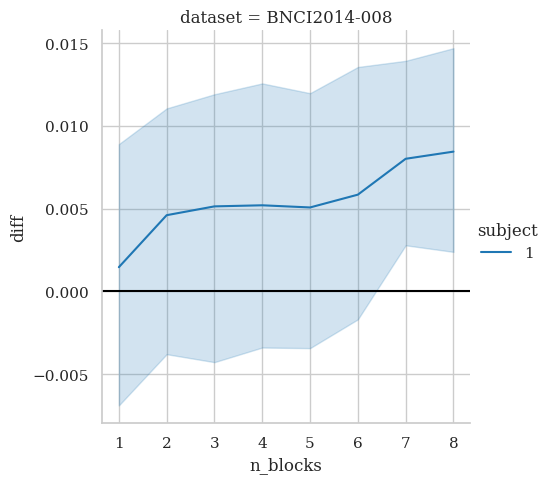

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(
    data=df,
    col='dataset',
    #col_wrap=4,
    x='n_blocks',
    y='diff',
    hue='subject',
    kind="line",
    palette="tab10",
    #ci=None,
    #units='fold',
    #estimator=None,
)
plt.axhline(0, color='black')
plt.show()